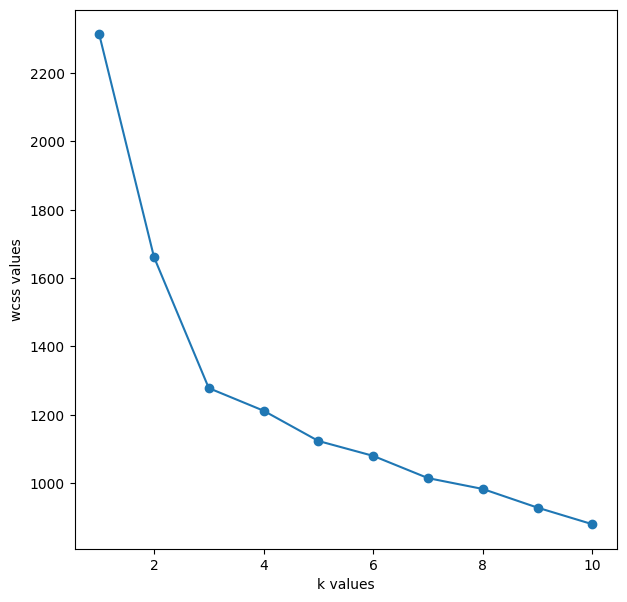

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  clusters  
0        

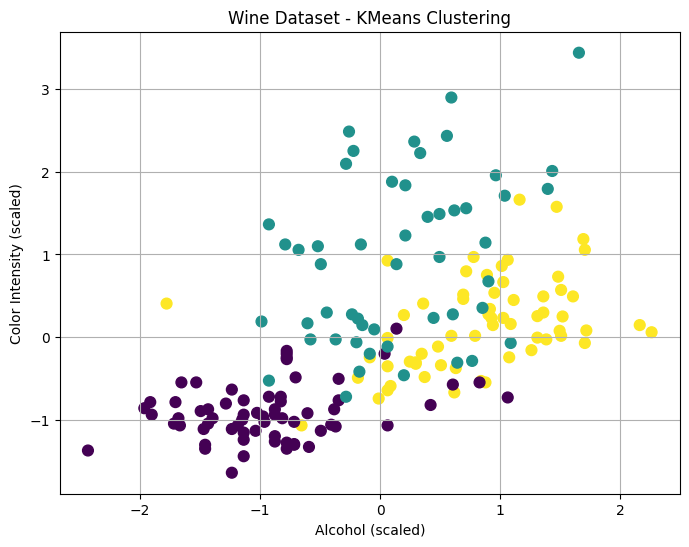

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.datasets import load_wine

wine=load_wine()
x=wine.data
feature=wine.feature_names

df=pd.DataFrame(x, columns=feature)

standard=StandardScaler()
x_standard_scaler=standard.fit_transform(x)

wcss=[]
for i in range(1, 11):
  model=KMeans(n_clusters=i, init="k-means++", random_state=42)
  model.fit(x_standard_scaler)
  wcss.append(model.inertia_)


plt.figure(figsize=(7, 7))
plt.plot(range(1, 11), wcss, marker="o")
plt.xlabel("k values")
plt.ylabel("wcss values")
plt.show()

i=3
model=KMeans(n_clusters=i, init="k-means++", random_state=42)
clusters=model.fit_predict(x_standard_scaler)

df["clusters"]=clusters

print(df.head())

plt.figure(figsize=(8,6))
plt.scatter(
    x_standard_scaler[:,0],
    x_standard_scaler[:,9],
    c=clusters,
    cmap="viridis",
    s=60
)


plt.title("Wine Dataset - KMeans Clustering")
plt.xlabel("Alcohol (scaled)")
plt.ylabel("Color Intensity (scaled)")
plt.grid(True)
plt.show()